In [1]:
import pandas as pd
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [3]:
urllib.request.urlretrieve(data, 'data.csv')


('data.csv', <http.client.HTTPMessage at 0x175000e3190>)

In [4]:
df = pd.read_csv('data.csv')
df_copy = df.copy()
df_copy.columns = df_copy.columns.str.lower().str.replace(' ', '_')
df_copy['log_mph'] = np.log1p(df_copy['fuel_efficiency_mpg'])


In [5]:
# question 1

df_copy.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
log_mph                  0
dtype: int64

In [6]:
# question 2

df_copy['horsepower'].astype(float).median()

# Homework question two lists only these options?
#204 I chose this because it was the closest
#254
#304
#354

np.float64(254.0)

(array([4.000e+00, 1.500e+01, 5.800e+01, 9.900e+01, 2.890e+02, 5.280e+02,
        7.580e+02, 1.192e+03, 1.362e+03, 1.310e+03, 1.454e+03, 1.151e+03,
        7.410e+02, 4.460e+02, 3.240e+02, 1.750e+02, 5.800e+01, 2.800e+01,
        7.000e+00, 1.000e+00]),
 array([19.8 , 20.87, 21.94, 23.01, 24.08, 25.15, 26.22, 27.29, 28.36,
        29.43, 30.5 , 31.57, 32.64, 33.71, 34.78, 35.85, 36.92, 37.99,
        39.06, 40.13, 41.2 ]),
 <BarContainer object of 20 artists>)

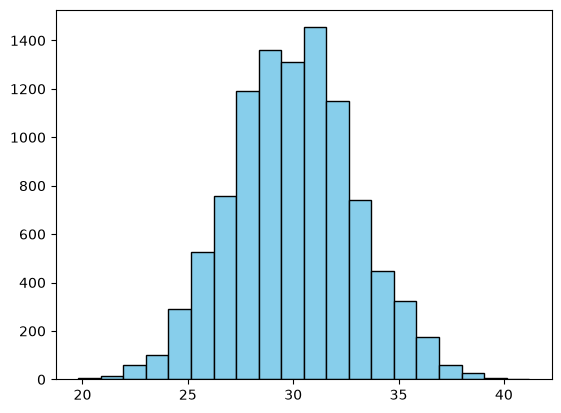

In [7]:
plt.hist(df_copy['fuel_efficiency_mpg'], bins=20, color='skyblue', edgecolor='black')


In [8]:
n = len(df_copy)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_copy.iloc[idx[:n_train]]
df_val = df_copy.iloc[idx[n_train:n_train + n_val]]
df_test = df_copy.iloc[idx[n_train + n_val:]]
y_train, y_val, y_test = [d['log_mph'].values for d in [df_train, df_val, df_test]]


In [9]:
def prepare_X(df, base_features, fill_value=0):
    df = df.copy()
    df_num = df[base_features]
    df_num = df_num.fillna(fill_value)
    X = df_num.values

    mu, sigma = X.mean(axis=0), X.std(axis=0)
    X_scale = (X - mu) / sigma

    return X_scale

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])      
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]            

def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [10]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']


In [11]:
# question 3

mean_mpg = df_train['fuel_efficiency_mpg'].mean()

for label, fill in [('zero', 0), ('mean', mean_mpg)]:
    X_tr = prepare_X(df_train, base, fill_value=fill)
    w0, w = train_linear_regression(X_tr, y_train)
    X_v = prepare_X(df_val, base, fill_value=fill)
    y_pred = w0 + X_v.dot(w)
    print(label, round(rmse(y_val, y_pred), 3))


zero 0.071
mean 0.071


In [17]:
# question 4

least_rmse = []

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train, base, fill_value=0)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val, base, fill_value=0)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    least_rmse.append((r, score))
r, score = min(least_rmse, key=lambda x: x[1])
print(r, round(score, 4))

0 0.0715


train=0.0713  val=0.0715  gap=0.0002
cond(X'X) = 5.6
  engine_displacement       VIF=1.90
  horsepower                VIF=1.18
  vehicle_weight            VIF=1.87
  model_year                VIF=1.13


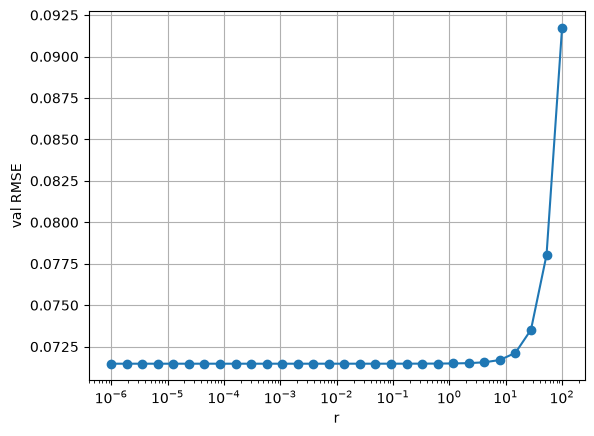

In [ ]:
# wanted to double check that regularization was not necessary, since min in Q4 came back as r=0

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_tr = prepare_X(df_train, base, fill_value=0)
X_v  = prepare_X(df_val,   base, fill_value=0)

# Train vs. val gap
w0, w = train_linear_regression(X_tr, y_train)
train_rmse = rmse(y_train, w0 + X_tr.dot(w))
val_rmse   = rmse(y_val,   w0 + X_v.dot(w))
print(f"train={train_rmse:.4f}  val={val_rmse:.4f}  gap={val_rmse - train_rmse:.4f}")

# Condition number
print(f"cond(X'X) = {np.linalg.cond(X_tr.T @ X_tr):.1f}")

# VIF per feature
for i, name in enumerate(base):
    print(f"  {name:25s} VIF={variance_inflation_factor(X_tr, i):.2f}")

# Lambda sweep
rs = np.logspace(-6, 2, 30)
val_rmses = []
for r in rs:
    w0, w = train_linear_regression_reg(X_tr, y_train, r=r)
    val_rmses.append(rmse(y_val, w0 + X_v.dot(w)))
plt.semilogx(rs, val_rmses, marker='o')
plt.xlabel('r'); plt.ylabel('val RMSE'); plt.grid()


In [14]:
# question 5
scores = []

for seed in range(10):
    np.random.seed(seed)
    idx = np.random.permutation(len(df_copy))
    df_shuffled = df_copy.iloc[idx].reset_index(drop=True)

    i1, i2 = int(0.6*len(df_shuffled)), int(0.8*len(df_shuffled))
    df_tr = df_shuffled.iloc[:i1].reset_index(drop=True)
    df_v  = df_shuffled.iloc[i1:i2].reset_index(drop=True)

    y_tr = df_tr.fuel_efficiency_mpg.values
    y_v  = df_v.fuel_efficiency_mpg.values

    X_tr = prepare_X(df_tr, base, fill_value=0)
    w0, w = train_linear_regression(X_tr, y_tr)

    X_v = prepare_X(df_v, base, fill_value=0)
    y_pred = w0 + X_v.dot(w)
    scores.append(rmse(y_v, y_pred))

print(round(np.std(scores), 3))

0.029


In [15]:
# question 6
df_q6 = df.copy()
df_q6.columns = df_q6.columns.str.lower().str.replace(' ', '_')
df_q6['log_mph'] = np.log1p(df_q6['fuel_efficiency_mpg'])

n = len(df_q6)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_full = df_q6.iloc[idx[:n_train + n_val]].reset_index(drop=True)
df_test_q6    = df_q6.iloc[idx[n_train + n_val:]].reset_index(drop=True)

y_train_full = df_train_full['fuel_efficiency_mpg'].values
y_test_q6    = df_test_q6['fuel_efficiency_mpg'].values


X_train_full = prepare_X(df_train_full, base, fill_value=0)
w0, w = train_linear_regression_reg(X_train_full, y_train_full, r=0.001)

X_test = prepare_X(df_test_q6, base, fill_value=0)
y_pred = w0 + X_test.dot(w)
print(round(rmse(y_test_q6, y_pred), 2))


2.24
